# Data Sets EDA

Three datasets. Two are from the WHO Health Inequality Data Repository, downloaded as `data (2).xlsx` and `data (3).xlsx`. One is from the World Bank Data360 portal, downloaded as `WB_INFECDB.csv`. The two WHO files share the same long format: one row per country, year, indicator and inequality dimension, things like sex, wealth, education or region. They cover different health topics. The World Bank file is built differently. It has no inequality dimension, just one row per country, year and indicator.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

bg = "#EFE6D3"
c1, c2, c3, c4 = "#B0552F", "#3F6F6F", "#C9A227", "#6E6250"

## 1. Health Care System and Access

This file has indicators about access to health services. It covers treatment coverage for diabetes and hypertension, cataract surgery, assistive technology, medical staff numbers, and financial hardship from health spending. It covers 197 countries from about 1990 to 2023. Each row is one country, one year, one indicator, split by a dimension. The dimensions are things like sex, wealth quintile, age group, household type, or whether someone lives in a city or in the countryside.

In [2]:
# load
health = pd.read_excel("data/data (2).xlsx", sheet_name="Data", engine="calamine")
print(health.shape)
health.head()

(99976, 24)


,setting,date,source,indicator_abbr,indicator_name,dimension,subgroup,estimate,se,ci_lb,...,iso3,favourable_indicator,indicator_scale,ordered_dimension,subgroup_order,reference_subgroup,whoreg6,wbincome2025,update,dataset_id
0,Afghanistan,1990,WHO Global Health Observatory,NCD_DIABETES_TREATMENT_AGESTD,Diabetes treatment coverage (30+ years) (age-s...,Sex,Female,21.155295,NaN,8.117738,...,AFG,1,100,0,0,0,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_hc
1,Afghanistan,1990,WHO Global Health Observatory,NCD_DIABETES_TREATMENT_AGESTD,Diabetes treatment coverage (30+ years) (age-s...,Sex,Male,23.483698,NaN,8.475509,...,AFG,1,100,0,0,1,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_hc
2,Afghanistan,1990,WHO Global Health Observatory,NCD_DIABETES_TREATMENT_CRUDE,Diabetes treatment coverage (30+ years) (crude...,Sex,Female,20.333025,NaN,7.813519,...,AFG,1,100,0,0,0,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_hc
3,Afghanistan,1990,WHO Global Health Observatory,NCD_DIABETES_TREATMENT_CRUDE,Diabetes treatment coverage (30+ years) (crude...,Sex,Male,22.687779,NaN,8.013305,...,AFG,1,100,0,0,1,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_hc
4,Afghanistan,1990,WHO Global Health Observatory,NCD_HYP_CONTROL_A,Hypertension effective treatment coverage amon...,Sex,Female,3.900000,NaN,0.300000,...,AFG,1,100,0,0,0,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_hc


In [3]:
# se, population and flag are empty for every single row here, so they carry no information
print(health[["se", "population", "flag"]].isna().sum())
health = health.drop(columns=["se", "population", "flag"])

print("duplicate rows:", health.duplicated().sum())
print("missing estimate:", health["estimate"].isna().sum(), "of", len(health))
health = health.dropna(subset=["estimate"])

se            99976
population    99976
flag          99976
dtype: int64


duplicate rows:

 0
missing estimate: 96 of 99976


In [4]:
# what the file actually holds
print("countries:", health["setting"].nunique())
print("years:", health["date"].min(), "-", health["date"].max())
print("indicators:", health["indicator_name"].nunique())
print("dimensions:", health["dimension"].unique())
health["estimate"].describe()

countries: 197
years: 1980 - 2023
indicators: 33
dimensions: <ArrowStringArray>
[                   'Sex',  'Household composition',        'Economic status',
     'Place of residence', 'Age (9 groups) (0-80+)']
Length: 5, dtype: str


count    99880.000000
mean        22.932742
std         19.829058
min          0.000000
25%          6.000000
50%         17.800000
75%         36.942057
max        100.000000
Name: estimate, dtype: float64

In [5]:
# one row per country and year, with each indicator as its own column, makes indicators easy to compare directly
health_nat = health.drop_duplicates(subset=["setting", "date", "indicator_name"])
health_wide = health_nat.pivot(index=["setting", "date"], columns="indicator_name", values="setting_average")
print(health_wide.shape)

diabetes_col = "Diabetes treatment coverage (30+ years) (age-standardized) (%)"
hypertension_col = "Hypertension effective treatment coverage among adults aged 30-79 years with hypertension (age-standardized) (%)"
print("correlation, diabetes vs hypertension treatment coverage:",
      round(health_wide[diabetes_col].corr(health_wide[hypertension_col]), 2))

(6595, 33)
correlation, diabetes vs hypertension treatment coverage: 0.7


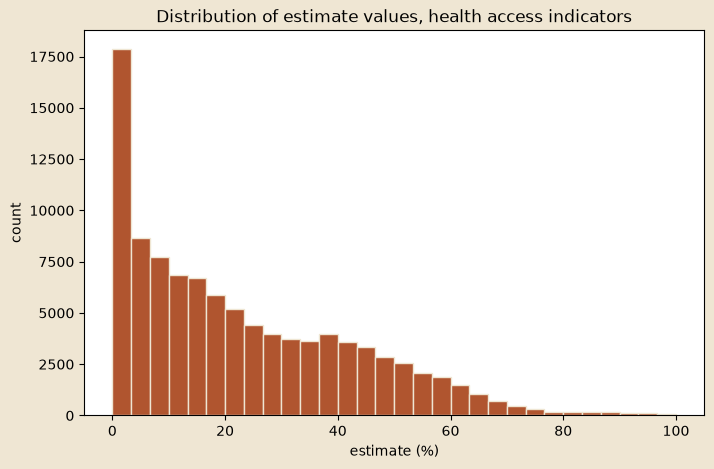

In [6]:
# every indicator here sits on the same 0-100 scale, so a histogram of the raw estimate is meaningful
plt.figure(figsize=(8, 5), facecolor=bg)
plt.hist(health["estimate"], bins=30, color=c1, edgecolor=bg)
plt.title("Distribution of estimate values, health access indicators")
plt.xlabel("estimate (%)")
plt.ylabel("count")
plt.savefig("images/fig1_health_access_hist.png", dpi=150, facecolor=bg)
plt.show()

subgroup
Female    42.450348
Male      39.866183
Name: estimate, dtype: float64


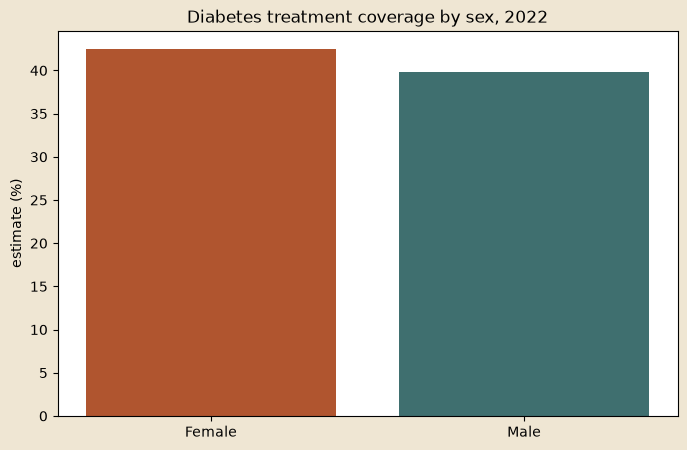

In [7]:
# diabetes treatment coverage, male vs female, most recent year
name = "Diabetes treatment coverage (30+ years) (age-standardized) (%)"
diab = health[health["indicator_name"] == name]
latest = diab["date"].max()
by_sex = diab[diab["date"] == latest].groupby("subgroup")["estimate"].mean()
print(by_sex)

plt.figure(figsize=(8, 5), facecolor=bg)
plt.bar(by_sex.index, by_sex.values, color=[c1, c2])
plt.title(f"Diabetes treatment coverage by sex, {latest}")
plt.ylabel("estimate (%)")
plt.savefig("images/fig2_diabetes_by_sex.png", dpi=150, facecolor=bg)
plt.show()

**Interpreting this dataset**

> Every row is one country, year, indicator and subgroup, so comparing numbers means filtering to one `indicator_name`, or putting each indicator in its own column. Diabetes and hypertension treatment coverage correlate at 0.7. Diabetes coverage is a bit higher for women than men.
>
> Problem this data could help answer: which countries treat one chronic condition well but not the other, and could learn from their own health system to close that gap?

## 2. Child Mortality, Growth and Nutrition

This file mixes child survival with child body size. It has infant and under-five mortality rates, stunting and overweight in children under five, overweight in school-age children, adolescent birth rate, and two air pollution indicators. It covers 197 countries from 1950 to 2024. The indicators are not all on the same scale. Mortality is deaths per 1000 births. Most others are a percent. The air pollution indicators are measured in DALYs, short for Disability-Adjusted Life Years, a way of counting healthy years of life lost to illness or early death, per 100000 people.

In [8]:
# load
child = pd.read_excel("data/data (3).xlsx", sheet_name="data", engine="calamine")
print(child.shape)
child.head()

(141875, 24)


,setting,date,source,indicator_abbr,indicator_name,dimension,subgroup,estimate,se,ci_lb,...,iso3,favourable_indicator,indicator_scale,ordered_dimension,subgroup_order,reference_subgroup,whoreg6,wbincome2025,update,dataset_id
0,Afghanistan,1957,WHO Global Health Observatory,MDG_0000000001,Infant mortality rate (deaths per 1000 live bi...,Sex,Female,247.968162,NaN,194.625473,...,AFG,0,1000,0,0,0,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_rmnch
1,Afghanistan,1957,WHO Global Health Observatory,MDG_0000000001,Infant mortality rate (deaths per 1000 live bi...,Sex,Male,272.898981,NaN,214.032553,...,AFG,0,1000,0,0,1,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_rmnch
2,Afghanistan,1957,WHO Global Health Observatory,MDG_0000000007,Under-five mortality rate (model-based estimat...,Sex,Female,363.074361,NaN,286.019402,...,AFG,0,1000,0,0,0,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_rmnch
3,Afghanistan,1957,WHO Global Health Observatory,MDG_0000000007,Under-five mortality rate (model-based estimat...,Sex,Male,379.310303,NaN,297.924681,...,AFG,0,1000,0,0,1,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_rmnch
4,Afghanistan,1958,WHO Global Health Observatory,MDG_0000000001,Infant mortality rate (deaths per 1000 live bi...,Sex,Female,245.144576,NaN,197.317972,...,AFG,0,1000,0,0,0,Eastern Mediterranean,Low-income,17 October 2025,rep_gho_rmnch


In [9]:
# same three empty columns as the first file
print(child[["se", "population", "flag"]].isna().sum())
child = child.drop(columns=["se", "population", "flag"])

print("duplicate rows:", child.duplicated().sum())
print("missing estimate:", child["estimate"].isna().sum(), "of", len(child))
child = child.dropna(subset=["estimate"])

se            141875
population    141875
flag          141875
dtype: int64


duplicate rows: 0
missing estimate: 122 of 141875


In [10]:
# because indicators use different scales, a single describe() on estimate is not meaningful across indicators
print("countries:", child["setting"].nunique())
print("years:", child["date"].min(), "-", child["date"].max())
print("indicators:", child["indicator_name"].nunique())
print("all indicators here are unfavourable, higher is worse:", (child["favourable_indicator"] == 0).all())
child["indicator_scale"].value_counts()

countries: 197
years: 1950 - 2024
indicators: 12
all indicators here are unfavourable, higher is worse: True


indicator_scale
100       84756
1000      56265
100000      732
Name: count, dtype: int64

In [11]:
# one row per country and year, each indicator as its own column
child_nat = child.drop_duplicates(subset=["setting", "date", "indicator_name"])
child_wide = child_nat.pivot(index=["setting", "date"], columns="indicator_name", values="setting_average")
print(child_wide.shape)

u5_col = "Under-five mortality rate (model-based estimates) (deaths per 1000 live births)"
overweight_col = "Overweight prevalence among school-age children and adolescents (crude) (%)"
print("correlation, under-five mortality vs overweight prevalence:",
      round(child_wide[u5_col].corr(child_wide[overweight_col]), 2))

(12733, 12)
correlation, under-five mortality vs overweight prevalence: -0.61


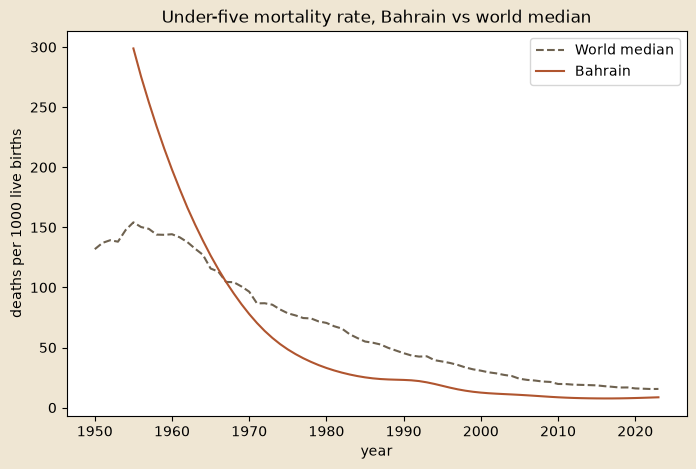

In [12]:
# under-five mortality, Bahrain against the world median
name = "Under-five mortality rate (model-based estimates) (deaths per 1000 live births)"
u5 = child[child["indicator_name"] == name]

# setting_average is the national figure, the same for every subgroup row of a country-year, so drop duplicates first
u5_nat = u5.drop_duplicates(subset=["setting", "date"])
world = u5_nat.groupby("date")["setting_average"].median()
bahrain = u5_nat[u5_nat["setting"] == "Bahrain"].set_index("date")["setting_average"]

plt.figure(figsize=(8, 5), facecolor=bg)
plt.plot(world.index, world.values, color=c4, linestyle="--", label="World median")
plt.plot(bahrain.index, bahrain.values, color=c1, label="Bahrain")
plt.title("Under-five mortality rate, Bahrain vs world median")
plt.xlabel("year")
plt.ylabel("deaths per 1000 live births")
plt.legend()
plt.savefig("images/fig3_u5mortality_bahrain.png", dpi=150, facecolor=bg)
plt.show()

{'Female': np.float64(24.914959966923075), 'Male': np.float64(28.06631113076923)}


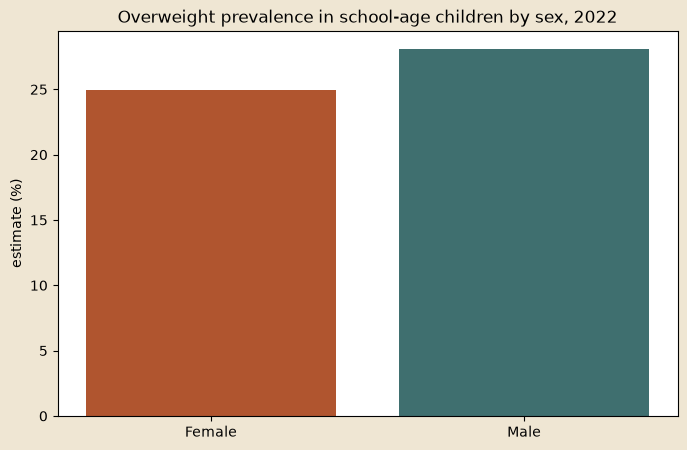

In [13]:
# overweight in school-age children, female vs male, latest year
f = child[child["indicator_name"] == "Overweight prevalence among school-age children and adolescents (crude) (%) - Female"]
m = child[child["indicator_name"] == "Overweight prevalence among school-age children and adolescents (crude) (%) - Male"]
latest = f["date"].max()
means = {"Female": f[f["date"] == latest]["estimate"].mean(), "Male": m[m["date"] == latest]["estimate"].mean()}
print(means)

plt.figure(figsize=(8, 5), facecolor=bg)
plt.bar(list(means.keys()), list(means.values()), color=[c1, c2])
plt.title(f"Overweight prevalence in school-age children by sex, {latest}")
plt.ylabel("estimate (%)")
plt.savefig("images/fig4_overweight_by_sex.png", dpi=150, facecolor=bg)
plt.show()

**Interpreting this dataset**

> Under-five mortality is the old story, decades of decline. Bahrain crossed below the world median around 1967 and is now near 8 deaths per 1000 births against a world median of 15. Overweight in school-age children is the newer story, rising instead of falling. Lower child mortality goes with higher child overweight, a correlation of -0.61, fitting an epidemiological transition.
>
> Problem this data could help answer: as under-five mortality falls, when should health policy start shifting toward child weight?

## 3. The Informal Economy

This file is the World Bank's Informal Economy Database, downloaded as `WB_INFECDB.csv`. It covers work and business done outside the formal, regulated economy: two estimates of the informal economy's size as a share of GDP, the total value of a country's yearly output, plus informal employment, self-employment, pension coverage, tax-cheating attitudes, and a few World Bank Enterprise Survey questions. One size estimate is called DGE, short for Dynamic General Equilibrium, a computer model of the whole economy. The other is MIMIC, short for Multiple Indicators Multiple Causes, a statistical method for estimating something we cannot measure directly. It covers 194 countries from 1990 to 2020, with no sex, age, or city versus countryside breakdown, just one row per country, year and indicator.

In [14]:
# load
informal = pd.read_csv("data/WB_INFECDB.csv")
print(informal.shape)
informal.head()

(46996, 35)


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,...,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,DZA,Algeria,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,...,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,...,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARG,Argentina,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,...,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARM,Armenia,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,...,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public


In [15]:
# a lot of columns are the same value on every single row, so they carry no information here
constant_cols = [c for c in informal.columns if informal[c].nunique() == 1]
print(constant_cols)
informal = informal.drop(columns=constant_cols)
print("duplicate rows:", informal.duplicated().sum())

['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']
duplicate rows: 0


In [16]:
# before dropping anything, check whether the missing values are random or follow a pattern
check = informal.groupby("INDICATOR_LABEL").agg(
    rows=("OBS_VALUE", "size"),
    countries=("REF_AREA_LABEL", "nunique"),
    years=("TIME_PERIOD", "nunique"),
    real=("OBS_VALUE", lambda s: s.notna().sum()),
)
check["grid_size"] = check["countries"] * check["years"]
check["coverage_pct"] = (check["real"] / check["rows"] * 100).round(1)
print("every indicator's row count equals its own country count times year count:",
      (check["rows"] == check["grid_size"]).all())
check[["rows", "real", "coverage_pct"]].sort_values("coverage_pct", ascending=False)

every indicator's row count equals its own country count times year count: True


,rows,real,coverage_pct
INDICATOR_LABEL,,,
Dynamic general equilibrium model-based (DGE) estimates of informal output (% of official GDP),4836,4834,100.0
Multiple indicators multiple causes model-based (MIMIC) estimates of informal output (% of official GDP),4898,4424,90.3
Self-employment (% of total employment),5487,2962,54.0
Employment outside the formal sector (% of total employment; International Labour Organization; hamonized series),3038,549,18.1
Informal employment (% of total employment; International Labour Organization; hamonized series),2976,527,17.7
Labor force with pension (% of labor force),4154,358,8.6
"Justifiable: Cheating on taxes (1 = never justifiable, 10 = always justifiable; simple country averages)",3069,247,8.0
Percent of firms identifying practices of competitors in the informal sector as a constraint (World Bank Enterprise Surveys),4650,298,6.4
Percent of firms competing against unregistered or informal firms (World Bank Enterprise Surveys),4650,297,6.4


In [17]:
# so this file is not randomly 68% empty, it is a template row for every year a country could have
# that indicator measured, and real coverage inside that template ranges from 100% (DGE) down to about
# 6% (the Enterprise Survey questions, which are done every few years per country, not every year)
print("missing OBS_VALUE:", informal["OBS_VALUE"].isna().sum(), "of", len(informal))
informal = informal.dropna(subset=["OBS_VALUE"])

missing OBS_VALUE: 31936 of 46996


In [18]:
# what the file actually holds, and how much real data survives per indicator
print("countries:", informal["REF_AREA_LABEL"].nunique())
print("years:", informal["TIME_PERIOD"].min(), "-", informal["TIME_PERIOD"].max())
print("indicators:", informal["INDICATOR_LABEL"].nunique())
print("units used:", informal["UNIT_MEASURE_LABEL"].unique())
informal.groupby("INDICATOR_LABEL")["OBS_VALUE"].count().sort_values(ascending=False)

countries: 194
years: 1990 - 2020
indicators: 11
units used: <ArrowStringArray>
['Percentage', 'Number', 'Score 0-10']
Length: 3, dtype: str


INDICATOR_LABEL
Dynamic general equilibrium model-based (DGE) estimates of informal output (% of official GDP)                                  4834
Multiple indicators multiple causes model-based (MIMIC) estimates of informal output (% of official GDP)                        4424
Self-employment (% of total employment)                                                                                         2962
Employment outside the formal sector (% of total employment; International Labour Organization; hamonized series)                549
Informal employment (% of total employment; International Labour Organization; hamonized series)                                 527
Labor force with pension (% of labor force)                                                                                      358
Percent of firms identifying practices of competitors in the informal sector as a constraint (World Bank Enterprise Surveys)     298
Percent of firms competing against unregistered or in

In [19]:
# one row per country and year, each indicator as its own column, this is what makes DGE and MIMIC directly comparable
informal_wide = informal.pivot_table(index=["REF_AREA_LABEL", "TIME_PERIOD"], columns="INDICATOR_LABEL", values="OBS_VALUE")
print(informal_wide.shape)
informal_wide.count().sort_values(ascending=False)

(5212, 11)


INDICATOR_LABEL
Dynamic general equilibrium model-based (DGE) estimates of informal output (% of official GDP)                                  4834
Multiple indicators multiple causes model-based (MIMIC) estimates of informal output (% of official GDP)                        4424
Self-employment (% of total employment)                                                                                         2962
Employment outside the formal sector (% of total employment; International Labour Organization; hamonized series)                549
Informal employment (% of total employment; International Labour Organization; hamonized series)                                 527
Labor force with pension (% of labor force)                                                                                      358
Percent of firms identifying practices of competitors in the informal sector as a constraint (World Bank Enterprise Surveys)     298
Percent of firms competing against unregistered or in

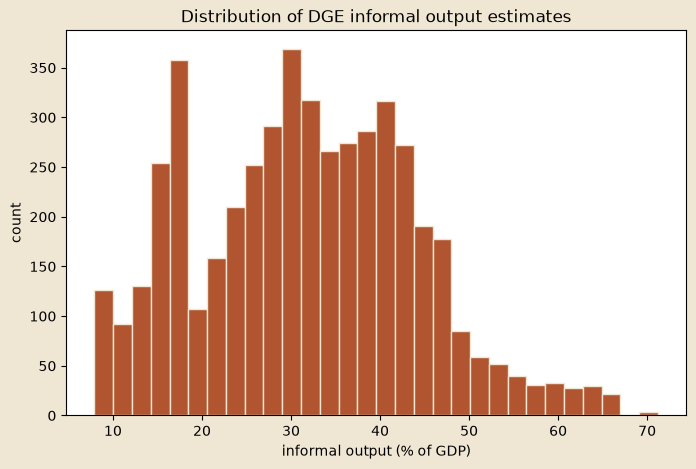

In [20]:
# DGE model estimate of informal output, % of GDP, one clean indicator on its own scale
dge_name = "Dynamic general equilibrium model-based (DGE) estimates of informal output (% of official GDP)"

plt.figure(figsize=(8, 5), facecolor=bg)
plt.hist(informal_wide[dge_name].dropna(), bins=30, color=c1, edgecolor=bg)
plt.title("Distribution of DGE informal output estimates")
plt.xlabel("informal output (% of GDP)")
plt.ylabel("count")
plt.savefig("images/fig5_informal_dge_hist.png", dpi=150, facecolor=bg)
plt.show()

country-years with both estimates: 4256 | correlation: 0.97


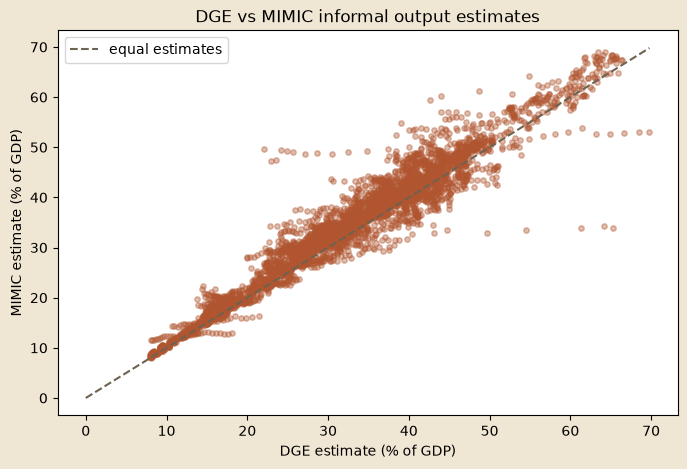

In [21]:
# this file stacks two different modelling approaches to the same question, so check if they agree
mimic_name = "Multiple indicators multiple causes model-based (MIMIC) estimates of informal output (% of official GDP)"
both = informal_wide[[dge_name, mimic_name]].dropna()
corr = both[dge_name].corr(both[mimic_name])
print("country-years with both estimates:", len(both), "| correlation:", round(corr, 2))

plt.figure(figsize=(8, 5), facecolor=bg)
plt.scatter(both[dge_name], both[mimic_name], color=c1, alpha=0.4, s=15)
lims = [0, both.values.max()]
plt.plot(lims, lims, color=c4, linestyle="--", label="equal estimates")
plt.title("DGE vs MIMIC informal output estimates")
plt.xlabel("DGE estimate (% of GDP)")
plt.ylabel("MIMIC estimate (% of GDP)")
plt.legend()
plt.savefig("images/fig6_informal_dge_vs_mimic.png", dpi=150, facecolor=bg)
plt.show()

**Interpreting this dataset**

> There is no subgroup breakdown here, just one row per country, year and indicator, so putting each indicator in its own column is what makes comparisons possible. The missing values are not random: country count times year count matches the row count for every indicator, so this file is a template grid. Coverage ranges from 100% for DGE and 90% for MIMIC down to about 6% for the Enterprise Survey questions, which run every few years per country, not annually. DGE and MIMIC still correlate at 0.97.
>
> Problem this data could help answer: does a country with a larger informal economy end up with lower pension coverage?